# StatsForecast with synthetic data

This guide compares a real-data baseline, fitting the same local model over a panel containing real and augmented series, and a synthetic-history forecast ensemble.

StatsForecast models such as `AutoETS` are fitted independently to each series. They do not share transferable weights. Adding synthetic series therefore does not change the model fitted to the observed series. The honest synthetic-only analogue is to fit local models to synthetic histories and aggregate their future paths—not to call that pretraining.

We use the classic [Box–Jenkins airline passenger series](https://search.r-project.org/R/refmans/datasets/html/AirPassengers.html). Its final 12 months are held out before `SynAugment` analyzes the training history.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsforecast import StatsForecast
from statsforecast.models import AutoETS

from synforecast import SynAugment

In [ ]:
HORIZON = 12
TARGET_ID = "AirPassengers"
data_path = Path("nbs/data/air_passengers.csv")
if not data_path.exists():
    data_path = Path("../../data/air_passengers.csv")

observed_df = pd.read_csv(data_path, parse_dates=["ds"])
train_df = observed_df.iloc[:-HORIZON].copy()
test_df = observed_df.iloc[-HORIZON:].copy()
train_df.tail()

,unique_id,ds,y
127,AirPassengers,1959-08-31,559.0
128,AirPassengers,1959-09-30,463.0
129,AirPassengers,1959-10-31,407.0
130,AirPassengers,1959-11-30,362.0
131,AirPassengers,1959-12-31,405.0


In [ ]:
augmented_train_df = SynAugment(seed=42).augment(
    train_df,
    n_augment=16,
    generator_override={TARGET_ID: "SARIMAGenerator"},
)
synthetic_history_df = augmented_train_df.loc[
    augmented_train_df["unique_id"].astype(str) != TARGET_ID
].copy()

pd.DataFrame(
    {
        "training set": ["observed only", "observed + augmented", "matched synthetic only"],
        "series": [1, augmented_train_df["unique_id"].nunique(), synthetic_history_df["unique_id"].nunique()],
    }
)

,training set,series
0,observed only,1
1,observed + augmented,17
2,matched synthetic only,16


In [ ]:
def make_forecaster() -> StatsForecast:
    return StatsForecast(
        models=[AutoETS(season_length=12)],
        freq="ME",
        n_jobs=1,
    )


def target_forecast(forecast_df: pd.DataFrame) -> pd.DataFrame:
    return forecast_df.loc[
        forecast_df["unique_id"].astype(str) == TARGET_ID,
        ["unique_id", "ds", "AutoETS"],
    ].copy()

In [ ]:
real_only = make_forecaster()
real_only.fit(train_df)
real_only_forecast = target_forecast(real_only.predict(h=HORIZON))

In [ ]:
with_augmentation = make_forecaster()
with_augmentation.fit(augmented_train_df)
augmented_forecast = target_forecast(with_augmentation.predict(h=HORIZON))

np.allclose(real_only_forecast["AutoETS"], augmented_forecast["AutoETS"])

True

For the synthetic-only workflow, `AutoETS` sees only histories produced by `SynAugment`. Averaging their forecasts creates a simulation ensemble on the target timeline. Generation parameters were estimated from the observed training split, but the local forecasting models receive no observed target values.

In [ ]:
synthetic_models = make_forecaster()
synthetic_models.fit(synthetic_history_df)
synthetic_paths = synthetic_models.predict(h=HORIZON)
synthetic_ensemble_forecast = (
    synthetic_paths.groupby("ds", as_index=False, observed=True)["AutoETS"]
    .mean()
    .assign(unique_id=TARGET_ID)
    [["unique_id", "ds", "AutoETS"]]
)

In [ ]:
forecast_sets = {
    "Observed only": real_only_forecast,
    "Observed + synthetic panel": augmented_forecast,
    "Synthetic-only ensemble": synthetic_ensemble_forecast,
}
comparison = test_df[["unique_id", "ds", "y"]].copy()
for label, forecast_df in forecast_sets.items():
    comparison = comparison.merge(
        forecast_df.rename(columns={"AutoETS": label}),
        on=["unique_id", "ds"],
        how="left",
    )

metrics = pd.DataFrame(
    {
        "workflow": list(forecast_sets),
        "MAE": [
            (comparison[label] - comparison["y"]).abs().mean()
            for label in forecast_sets
        ],
    }
).sort_values("MAE")
metrics

,workflow,MAE
0,Observed only,35.612471
1,Observed + synthetic panel,35.612471
2,Synthetic-only ensemble,105.345946


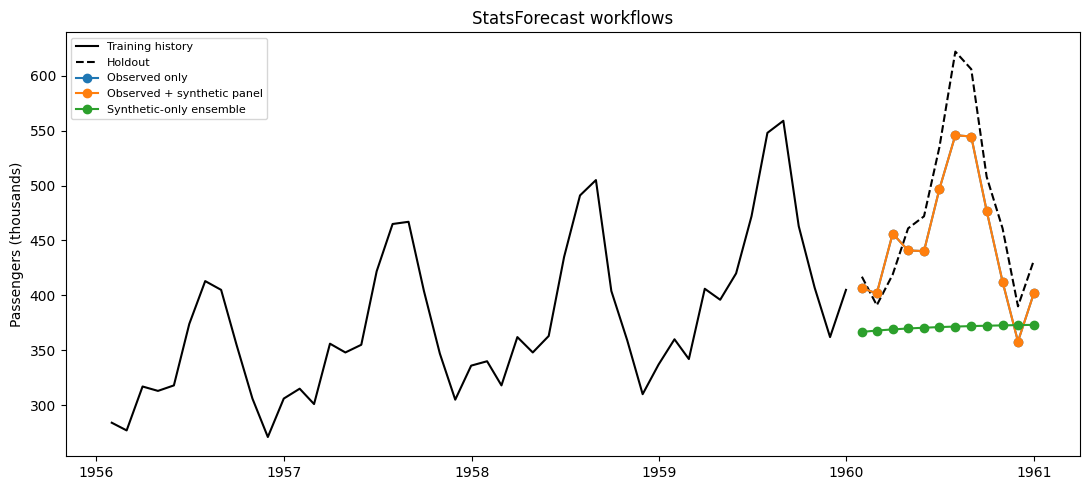

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
history = train_df.tail(48)
ax.plot(history["ds"], history["y"], color="black", label="Training history")
ax.plot(test_df["ds"], test_df["y"], color="black", linestyle="--", label="Holdout")
for label in forecast_sets:
    ax.plot(comparison["ds"], comparison[label], marker="o", label=label)
ax.set(title="StatsForecast workflows", ylabel="Passengers (thousands)")
ax.legend(fontsize=8)
fig.tight_layout()

Synthetic panels are useful with StatsForecast for simulation, stress testing, and forecast distributions across plausible histories. They do not augment the parameter fit of an existing local model unless a custom pooling or ensembling strategy is introduced.